# Experiment 6 — Dimensionality Reduction and Model Evaluation (With and Without PCA)

**Course:** ICS1512 – Machine Learning Algorithms Laboratory
**Name:** Emmanuel Maximus Ravichandran &nbsp;|&nbsp; **Register Number:** 3122247001015
**Faculty:** Dr. Poreddy Ajay Kumar Reddy

**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC) — 569 samples, 30 numerical features, binary target (Malignant / Benign)

This notebook trains and tunes **10 classifiers** — SVM, Naive Bayes, KNN, Logistic Regression,
Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost, and a Stacked Ensemble — both
**without PCA** (original 30-feature space) and **with PCA** (reduced feature space retaining 95%
variance), using 5-fold cross-validation for hyperparameter selection in every case, then compares
which models benefit from dimensionality reduction and which do not.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import time
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                              precision_recall_curve, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Objective

To study the effect of dimensionality reduction using Principal Component Analysis (PCA) on the
performance of ten machine learning classifiers. Specifically:

a) Train and validate models **without PCA** (original feature space).
b) Train and validate models **with PCA** (reduced feature space).

For both cases, perform hyperparameter tuning with 5-fold cross-validation and record and compare
performance, to determine when PCA helps and when it does not.

## 2. Problem Statement

**Input:** 30 numerical features computed from digitized images of a fine needle aspirate (FNA) of
a breast mass, describing characteristics of the cell nuclei present (radius, texture, perimeter,
area, smoothness, compactness, concavity, symmetry, fractal dimension, etc., each reported as
mean, standard error, and "worst"/largest value).

**Output:** Binary classification — whether the mass is **malignant** or **benign**.

**Objective:** Build and tune ten classifiers on the original 30-feature space and on a
PCA-reduced feature space (95% cumulative explained variance), using identical 5-fold
cross-validated hyperparameter search in both cases, then quantify whether — and for which model
families — PCA improves accuracy, F1-score, and cross-validation stability, or instead costs
accuracy for a reduction in dimensionality.

## 3. Dataset Description

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0 = malignant, 1 = benign
target_names = data.target_names

print("Dataset name: Wisconsin Diagnostic Breast Cancer (WDBC)")
print("Dataset source: UCI ML Repository / sklearn.datasets.load_breast_cancer")
print("Shape:", df.shape)
print("Number of features:", df.shape[1]-1)
print("Classes:", dict(enumerate(target_names)))
print("Class distribution:\n", df["target"].value_counts().rename(index={0:"malignant",1:"benign"}))
print("Missing values:", df.isnull().sum().sum())

Dataset name: Wisconsin Diagnostic Breast Cancer (WDBC)
Dataset source: UCI ML Repository / sklearn.datasets.load_breast_cancer
Shape: (569, 31)
Number of features: 30
Classes: {0: np.str_('malignant'), 1: np.str_('benign')}
Class distribution:
 target
benign       357
malignant    212
Name: count, dtype: int64
Missing values: 0


| Field | Value |
|---|---|
| Dataset Name | Wisconsin Diagnostic Breast Cancer (WDBC) |
| Dataset Source | UCI ML Repository (via `sklearn.datasets.load_breast_cancer`) |
| Number of Samples | 569 |
| Number of Features | 30 (numeric, real-valued) |
| Number of Classes | 2 (malignant = 0, benign = 1) |
| Missing Values | 0 |
| Train-Test Split | 80% / 20%, stratified on target |

## 4. Exploratory Data Analysis

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


**Inference:** The statistical summary shows all 30 features are continuous and positive, but on very different scales (e.g. `mean area` runs into the hundreds/thousands while `mean smoothness` is a small fraction) — this scale mismatch is exactly why standardization is required before PCA and before any distance- or margin-based model (SVM, KNN, Logistic Regression). Several "worst" columns have visibly larger spread than their "mean" counterparts, hinting at skew driven by a subset of aggressive tumors.

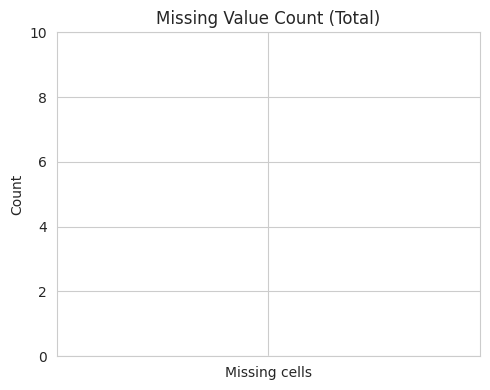

Missing values per column (all zero):
0 total missing cells across 17639 cells


In [4]:
plt.figure(figsize=(5,4))
missing = df.isnull().sum()
plt.bar(["Missing cells"], [missing.sum()])
plt.ylim(0, max(10, missing.sum()+5))
plt.title("Missing Value Count (Total)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print("Missing values per column (all zero):")
print(missing.sum(), "total missing cells across", df.shape[0]*df.shape[1], "cells")

**Inference:** The dataset has zero missing values across all 569 samples and 30 features, so no imputation strategy is required — preprocessing can go straight to scaling.

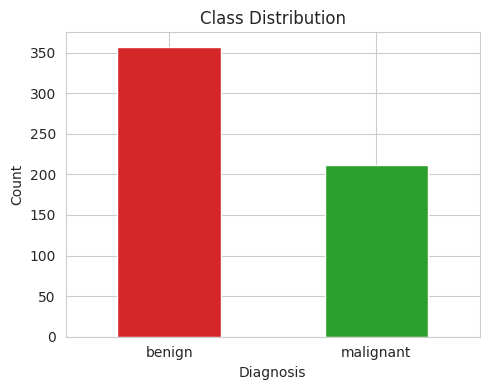

target
benign       357
malignant    212
Name: count, dtype: int64
Class ratio (benign:malignant) = 1.68 : 1


In [5]:
plt.figure(figsize=(5,4))
counts = df["target"].value_counts().rename(index={0:"malignant",1:"benign"})
counts.plot(kind="bar", color=["#d62728","#2ca02c"])
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(counts)
print(f"Class ratio (benign:malignant) = {counts['benign']/counts['malignant']:.2f} : 1")

**Inference:** The classes are moderately imbalanced (roughly 1.68:1 benign to malignant), not severely enough to require resampling, but enough to justify stratified train-test splitting and stratified k-fold cross-validation (both used throughout this notebook) so every fold preserves the same class ratio, and to justify tracking F1/ROC-AUC alongside raw accuracy.

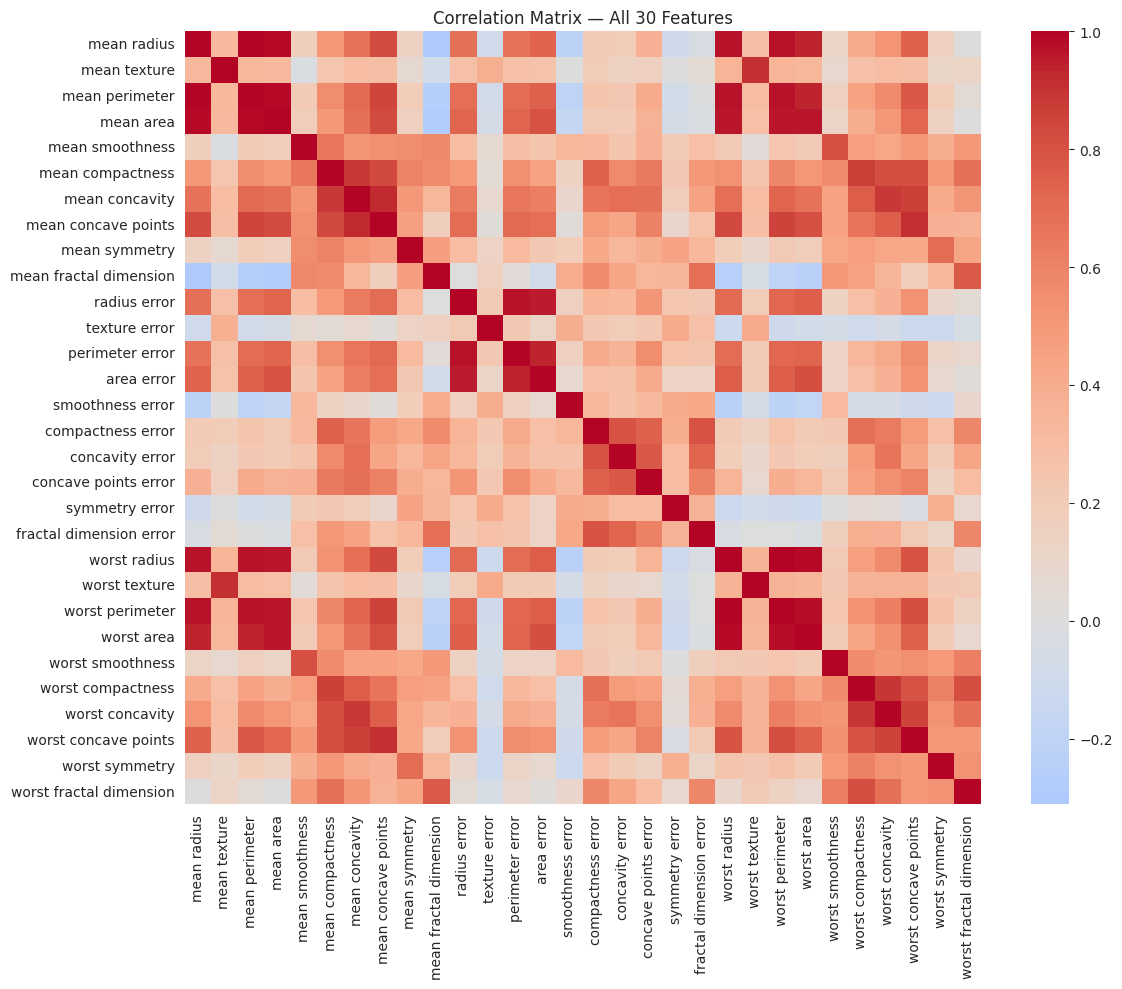

Top 5 most correlated feature pairs:
mean radius     mean perimeter     0.997855
worst radius    worst perimeter    0.993708
mean radius     mean area          0.987357
mean perimeter  mean area          0.986507
worst radius    worst area         0.984015
dtype: float64


In [6]:
plt.figure(figsize=(12,10))
corr = df.drop(columns=["target"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, xticklabels=True, yticklabels=True)
plt.title("Correlation Matrix — All 30 Features")
plt.tight_layout()
plt.show()

# report the most correlated pairs
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("Top 5 most correlated feature pairs:")
print(corr_pairs.abs().sort_values(ascending=False).head(5))

**Inference:** Many features are extremely highly correlated (e.g. `mean radius` / `mean perimeter` / `mean area` are near-collinear, since they all measure tumor size in different units), and each "mean" feature is strongly correlated with its own "worst" counterpart. This heavy redundancy is precisely the condition under which PCA is expected to help most: a handful of principal components should be able to capture almost all of the variance that 30 correlated raw features carry, which is confirmed later in the PCA scree plot.

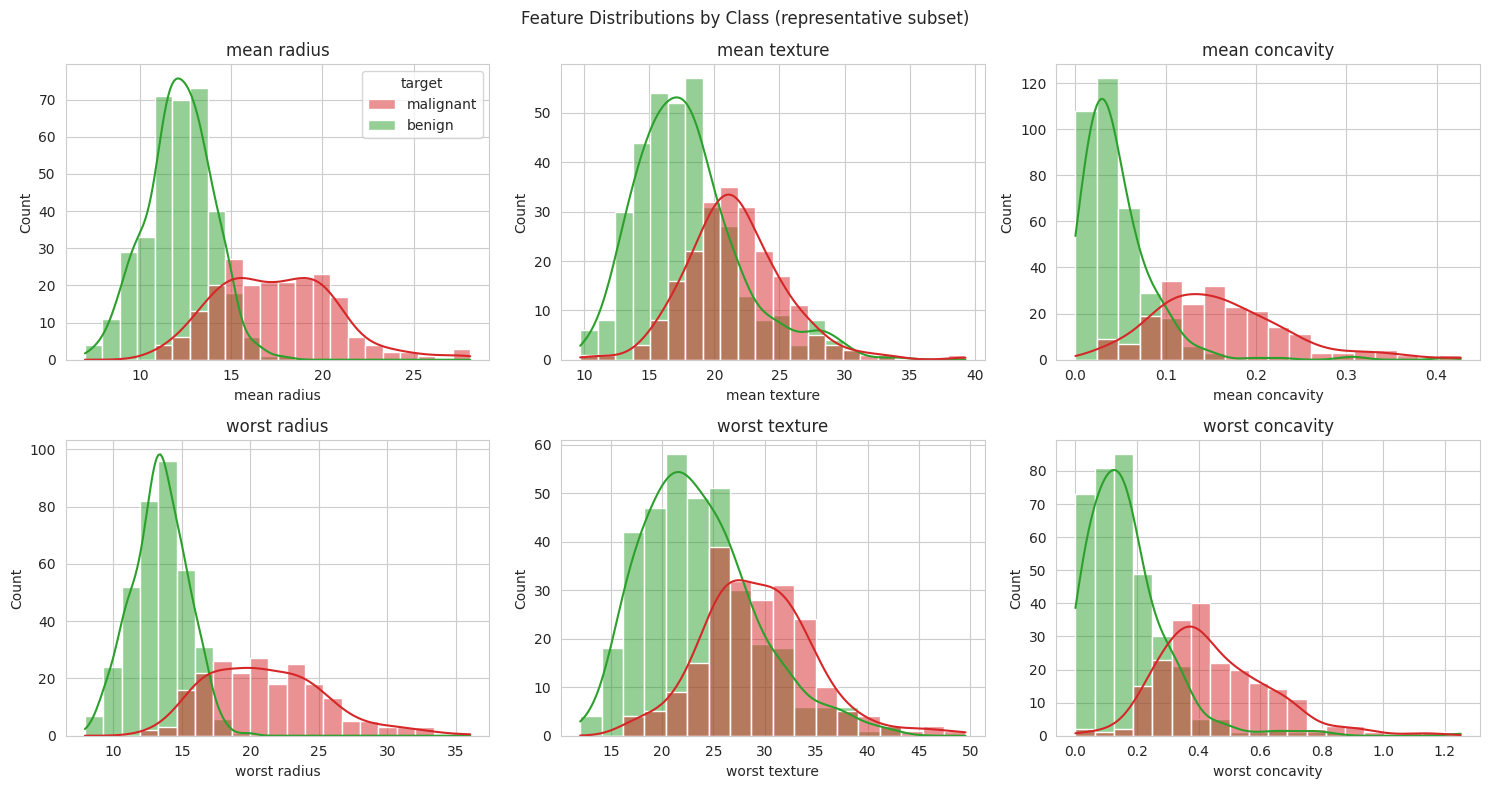

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
sample_feats = ["mean radius", "mean texture", "mean concavity",
                 "worst radius", "worst texture", "worst concavity"]
for ax, feat in zip(axes.ravel(), sample_feats):
    sns.histplot(data=df, x=feat, hue=df["target"].map({0:"malignant",1:"benign"}),
                 kde=True, ax=ax, palette=["#d62728","#2ca02c"], legend=(feat==sample_feats[0]))
    ax.set_title(feat)
plt.suptitle("Feature Distributions by Class (representative subset)")
plt.tight_layout()
plt.show()

**Inference:** For every feature shown, the malignant-class distribution is shifted toward higher values with a longer right tail (larger, more irregular nuclei), while benign cases cluster at lower values with tighter spread. The visible class separation, even on individual 1-D features, explains why relatively simple linear models (Logistic Regression, linear SVM) already perform strongly on this dataset.

## 5. Data Preprocessing

- Missing values: none (confirmed above).
- Encoding: target already numeric (0 = malignant, 1 = benign).
- Feature scaling: `StandardScaler`, fit on train only, applied to test — required before PCA and
  for scale-sensitive models (SVM, KNN, Logistic Regression, Stacking's meta-learner).
- Train-test split: 80–20, stratified on the target.
- Feature engineering: none — all 30 provided features are used directly (dimensionality
  reduction is handled separately via PCA, compared against the untouched feature set).

In [8]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (455, 30)  Test shape: (114, 30)
Train class balance:
 target
1    0.626
0    0.374
Name: proportion, dtype: float64
Test class balance:
 target
1    0.632
0    0.368
Name: proportion, dtype: float64


## 6. Machine Learning Algorithms

Brief working principle, mathematical formulation, advantages, and limitations for each of the
ten classifiers compared in this experiment.

**Support Vector Machine (SVM).** Finds the hyperplane $w^Tx+b=0$ that maximizes the margin
between classes, solving $\min \tfrac12\|w\|^2 + C\sum_i \xi_i$ subject to
$y_i(w^Tx_i+b)\ge 1-\xi_i$; non-linear boundaries via the kernel trick (e.g. RBF
$K(x,x')=\exp(-\gamma\|x-x'\|^2)$). *Advantages:* effective in high dimensions, robust to
overfitting with the right margin/kernel. *Limitations:* slow on large datasets, sensitive to
feature scaling and kernel/hyperparameter choice.

**Naive Bayes (Gaussian).** Applies Bayes' theorem
$P(y\mid x)\propto P(y)\prod_j P(x_j\mid y)$ assuming features are conditionally independent
given the class, with $P(x_j\mid y)$ modeled as Gaussian. *Advantages:* fast, needs little data,
works well as a baseline. *Limitations:* the independence assumption rarely holds exactly (and is
violated further once PCA introduces linear combinations of features).

**k-Nearest Neighbors (KNN).** Classifies a point by majority vote (optionally distance-weighted)
among its $k$ nearest neighbors under a distance metric (Euclidean/Manhattan). *Advantages:*
simple, no training phase, naturally non-linear. *Limitations:* slow at inference on large data,
sensitive to feature scale and the curse of dimensionality.

**Logistic Regression.** Models $P(y=1\mid x)=\sigma(w^Tx+b)=\tfrac{1}{1+e^{-(w^Tx+b)}}$,
fit by maximizing the log-likelihood (equivalently minimizing log-loss, with $L2$ regularization
strength $1/C$). *Advantages:* fast, interpretable, well-calibrated probabilities. *Limitations:*
assumes a linear decision boundary in feature space.

**Decision Tree.** Recursively splits feature space to maximize purity of child nodes, using
Gini impurity $1-\sum_k p_k^2$ or entropy $-\sum_k p_k\log p_k$ as the split criterion.
*Advantages:* interpretable, handles non-linear boundaries and mixed feature scales natively.
*Limitations:* prone to overfitting/high variance without depth/leaf constraints.

**Random Forest.** Bagged ensemble of decision trees, each trained on a bootstrap sample with a
random feature subset per split; prediction is the majority vote. *Advantages:* reduces variance
versus a single tree, robust to noise and irrelevant features. *Limitations:* less interpretable,
larger memory/inference cost than one tree.

**AdaBoost.** Sequentially fits weak learners (decision stumps), reweighting misclassified
samples after each round and combining learners as a weighted vote
$H(x)=\text{sign}\sum_t \alpha_t h_t(x)$. *Advantages:* strong accuracy from simple weak
learners, few hyperparameters. *Limitations:* sensitive to noisy data/outliers, which get
up-weighted round after round.

**Gradient Boosting.** Sequentially fits new trees to the negative gradient (residuals) of a
differentiable loss function w.r.t. the current ensemble's predictions, additively improving the
model. *Advantages:* typically very high accuracy on tabular data. *Limitations:* slower to
train, more hyperparameters to tune, can overfit without shrinkage/depth control.

**XGBoost.** A regularized, second-order (Newton-boosted) gradient boosting implementation adding
an explicit regularization term on tree complexity to the loss objective. *Advantages:* fast,
regularized, usually matches or beats plain Gradient Boosting. *Limitations:* many
hyperparameters, can still overfit small datasets if unconstrained.

**Stacking.** Trains several diverse base learners (here: SVM, Naive Bayes, Decision Tree) and a
meta-learner (Logistic Regression) that learns how to combine their out-of-fold predictions.
*Advantages:* can outperform any individual base learner by exploiting complementary errors.
*Limitations:* more expensive to train/tune (nested cross-validation), harder to interpret.

## 7. Experimental Setup

In [9]:
import sklearn as _sk
print(f"Python Version      : {platform.python_version()}")
print(f"Scikit-Learn Version: {_sk.__version__}")
try:
    import xgboost as _xgb
    print(f"XGBoost Version     : {_xgb.__version__}")
except Exception:
    pass
print(f"IDE                 : Jupyter Notebook")
print(f"Operating System    : {platform.system()} {platform.release()}")
print(f"Hardware            : {platform.machine()}, {platform.processor() or 'N/A'}")

Python Version      : 3.12.3
Scikit-Learn Version: 1.8.0
XGBoost Version     : 3.4.1
IDE                 : Jupyter Notebook
Operating System    : Linux 6.18.44-fc-v37
Hardware            : x86_64, x86_64


## 8. PCA — Dimensionality Reduction

We choose components to retain **95% cumulative explained variance** (a variance target rather
than a fixed component count), fit only on the training set to avoid leakage.

In [10]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)

print(f"Components needed for >=95% variance: {n_components_95}")
print(f"Actual cumulative explained variance at that count: {cum_var[n_components_95-1]*100:.2f}%")

pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("With-PCA training shape:", X_train_pca.shape)

Components needed for >=95% variance: 10
Actual cumulative explained variance at that count: 95.27%
With-PCA training shape: (455, 10)


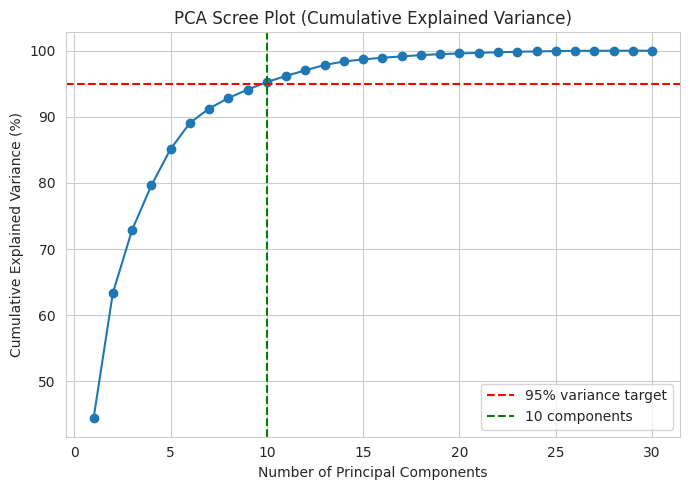

In [11]:
plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var)+1), cum_var*100, "o-")
plt.axhline(95, color="r", linestyle="--", label="95% variance target")
plt.axvline(n_components_95, color="g", linestyle="--", label=f"{n_components_95} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Scree Plot (Cumulative Explained Variance)")
plt.legend()
plt.tight_layout()
plt.show()

**PCA Summary**

| Setting | Chosen Components / Variance Target | Explained Variance (%) | Justification |
|---|---|---|---|
| With-PCA | 95% variance target | *(printed above)* | Retains almost all discriminative signal while cutting dimensionality roughly 3x, reducing overfitting risk and training cost for distance/margin-based models. |

## 9. Hyperparameter Selection — Grids and 5-Fold CV Setup

The same `StratifiedKFold(5)` split and the same hyperparameter grid are used for both the
No-PCA and With-PCA run of every model, so results are directly comparable.

In [12]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def run_grid(estimator, param_grid, X_tr, y_tr):
    grid = GridSearchCV(estimator, param_grid, cv=cv5,
                         scoring={"accuracy": "accuracy", "f1": "f1"},
                         refit="accuracy", n_jobs=-1)
    grid.fit(X_tr, y_tr)
    return grid

def fold_scores(grid):
    """Return the 5 per-fold accuracy scores and the mean, at the best hyperparameter index."""
    cvres = grid.cv_results_
    idx = grid.best_index_
    return [cvres[f"split{i}_test_accuracy"][idx] for i in range(5)]

model_specs = {
    "SVM": (SVC(probability=True, random_state=RANDOM_STATE),
            {"kernel": ["linear", "rbf"], "C": [0.1, 1, 10], "gamma": ["scale", "auto"]}),
    "Naive Bayes": (GaussianNB(), {"var_smoothing": np.logspace(-11, -7, 5)}),
    "KNN": (KNeighborsClassifier(),
            {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"],
             "metric": ["euclidean", "manhattan"]}),
    "Logistic Regression": (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                             {"C": [0.01, 0.1, 1, 10, 100]}),
    "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE),
                       {"max_depth": [3, 5, 7, None], "min_samples_split": [2, 5, 10],
                        "criterion": ["gini", "entropy"]}),
    "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE),
                       {"n_estimators": [50, 100, 200], "max_depth": [None, 5, 10],
                        "max_features": ["sqrt", "log2"]}),
    "AdaBoost": (AdaBoostClassifier(random_state=RANDOM_STATE),
                 {"n_estimators": [50, 100, 150], "learning_rate": [0.01, 0.1, 0.5, 1.0]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE),
                           {"n_estimators": [50, 100, 150], "learning_rate": [0.01, 0.1, 0.2],
                            "max_depth": [2, 3, 4]}),
    "XGBoost": (XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
                {"n_estimators": [50, 100, 150], "learning_rate": [0.01, 0.1, 0.2],
                 "max_depth": [2, 3, 4]}),
}
print("Models to tune:", list(model_specs.keys()), "+ Stacking")

Models to tune: ['SVM', 'Naive Bayes', 'KNN', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost'] + Stacking


### Hyperparameter Tuning — No-PCA vs With-PCA (all models)

For each model the same grid is fit once on the original 30-feature space and once on the
PCA-reduced space; `GridSearchCV.best_score_` is the mean 5-fold CV accuracy at the best
hyperparameter combination.

In [13]:
results = {}
t_all = time.time()
for name, (est, grid_params) in model_specs.items():
    t0 = time.time()
    g_nopca = run_grid(est, grid_params, X_train_scaled, y_train)
    g_pca = run_grid(est, grid_params, X_train_pca, y_train)
    results[name] = (g_nopca, g_pca)
    print(f"{name:20s} done in {time.time()-t0:5.1f}s | "
          f"Best NoPCA acc={g_nopca.best_score_:.4f} | Best PCA acc={g_pca.best_score_:.4f}")

# Stacking uses a smaller grid: nested nature of StackingClassifier (internal cv=5 across
# 3 base learners) inside an outer 5-fold GridSearchCV makes a large grid too expensive.
stack_base = StackingClassifier(
    estimators=[
        ("svm", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
        ("nb", GaussianNB()),
        ("dt", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5
)
stack_grid_params = {"final_estimator__C": [0.1, 1, 10]}
t0 = time.time()
g_stack_nopca = run_grid(stack_base, stack_grid_params, X_train_scaled, y_train)
g_stack_pca = run_grid(stack_base, stack_grid_params, X_train_pca, y_train)
results["Stacking"] = (g_stack_nopca, g_stack_pca)
print(f"{'Stacking':20s} done in {time.time()-t0:5.1f}s | "
      f"Best NoPCA acc={g_stack_nopca.best_score_:.4f} | Best PCA acc={g_stack_pca.best_score_:.4f}")

print(f"\nTotal tuning time: {time.time()-t_all:.1f}s")

SVM                  done in   1.3s | Best NoPCA acc=0.9758 | Best PCA acc=0.9780
Naive Bayes          done in   0.2s | Best NoPCA acc=0.9341 | Best PCA acc=0.9165


KNN                  done in   0.8s | Best NoPCA acc=0.9714 | Best PCA acc=0.9648


Logistic Regression  done in   0.2s | Best NoPCA acc=0.9824 | Best PCA acc=0.9824


Decision Tree        done in   1.5s | Best NoPCA acc=0.9319 | Best PCA acc=0.9385


Random Forest        done in  25.5s | Best NoPCA acc=0.9648 | Best PCA acc=0.9604


AdaBoost             done in  20.5s | Best NoPCA acc=0.9802 | Best PCA acc=0.9648


Gradient Boosting    done in  51.6s | Best NoPCA acc=0.9736 | Best PCA acc=0.9648


XGBoost              done in  10.3s | Best NoPCA acc=0.9714 | Best PCA acc=0.9670


Stacking             done in   2.2s | Best NoPCA acc=0.9714 | Best PCA acc=0.9692

Total tuning time: 114.1s


### Per-model hyperparameter tables (No-PCA vs With-PCA side by side)

In [14]:
def build_table(g_nopca, g_pca, param_cols):
    df_no = pd.DataFrame(g_nopca.cv_results_)
    df_pc = pd.DataFrame(g_pca.cv_results_)
    param_key_cols = [f"param_{p}" for p in param_cols]
    merged = df_no[param_key_cols + ["mean_test_accuracy"]].copy()
    merged.columns = param_cols + ["Avg CV Accuracy (No-PCA) %"]
    merged["Avg CV Accuracy (With-PCA) %"] = df_pc["mean_test_accuracy"].values
    merged["Avg CV Accuracy (No-PCA) %"] = (merged["Avg CV Accuracy (No-PCA) %"] * 100).round(2)
    merged["Avg CV Accuracy (With-PCA) %"] = (merged["Avg CV Accuracy (With-PCA) %"] * 100).round(2)
    return merged.sort_values("Avg CV Accuracy (No-PCA) %", ascending=False)

param_map = {
    "SVM": ["kernel", "C", "gamma"],
    "Naive Bayes": ["var_smoothing"],
    "KNN": ["n_neighbors", "weights", "metric"],
    "Logistic Regression": ["C"],
    "Decision Tree": ["max_depth", "min_samples_split", "criterion"],
    "Random Forest": ["n_estimators", "max_depth", "max_features"],
    "AdaBoost": ["n_estimators", "learning_rate"],
    "Gradient Boosting": ["n_estimators", "learning_rate", "max_depth"],
    "XGBoost": ["n_estimators", "learning_rate", "max_depth"],
    "Stacking": ["final_estimator__C"],
}

hyperparam_tables = {}
for name, cols in param_map.items():
    g_no, g_pc = results[name]
    t = build_table(g_no, g_pc, cols)
    hyperparam_tables[name] = t
    print(f"\n=== {name} (top 8 of {len(t)} combinations tried) ===")
    print(t.head(8).to_string(index=False))
    print(f"Best NoPCA params: {g_no.best_params_}  (CV acc {g_no.best_score_*100:.2f}%)")
    print(f"Best PCA params:   {g_pc.best_params_}  (CV acc {g_pc.best_score_*100:.2f}%)")


=== SVM (top 8 of 12 combinations tried) ===
kernel    C gamma  Avg CV Accuracy (No-PCA) %  Avg CV Accuracy (With-PCA) %
linear  0.1 scale                       97.58                         97.58
linear  0.1  auto                       97.58                         97.58
   rbf 10.0 scale                       96.92                         97.14
   rbf 10.0  auto                       96.92                         95.16
   rbf  1.0 scale                       96.70                         96.92
   rbf  1.0  auto                       96.70                         95.60
linear  1.0  auto                       96.48                         97.80
linear  1.0 scale                       96.48                         97.80
Best NoPCA params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}  (CV acc 97.58%)
Best PCA params:   {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}  (CV acc 97.80%)

=== Naive Bayes (top 8 of 5 combinations tried) ===
 var_smoothing  Avg CV Accuracy (No-PCA) %  Avg C

## 10. Results — 5-Fold Cross-Validation (All Models)

Per-fold accuracy at each model's own best hyperparameters, for No-PCA and With-PCA separately.

In [15]:
cv_rows_nopca, cv_rows_pca = [], []
summary_rows = []
for name, (g_no, g_pc) in results.items():
    f_no = fold_scores(g_no)
    f_pc = fold_scores(g_pc)
    cv_rows_nopca.append([name] + [round(s*100,2) for s in f_no] + [round(np.mean(f_no)*100,2)])
    cv_rows_pca.append([name] + [round(s*100,2) for s in f_pc] + [round(np.mean(f_pc)*100,2)])
    summary_rows.append({
        "Model": name,
        "Avg Accuracy % (No-PCA)": round(g_no.best_score_*100, 2),
        "Avg Accuracy % (With-PCA)": round(g_pc.best_score_*100, 2),
        "Delta (PCA - NoPCA)": round((g_pc.best_score_ - g_no.best_score_)*100, 2),
        "Std Fold Acc % (No-PCA)": round(np.std(f_no)*100, 2),
        "Std Fold Acc % (With-PCA)": round(np.std(f_pc)*100, 2),
    })

cvcols = ["Model", "Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5", "Avg"]
cv_table_nopca = pd.DataFrame(cv_rows_nopca, columns=cvcols)
cv_table_pca = pd.DataFrame(cv_rows_pca, columns=cvcols)
summary_df = pd.DataFrame(summary_rows).sort_values("Avg Accuracy % (With-PCA)", ascending=False)

print("=== 5-Fold CV Results — No-PCA ===")
print(cv_table_nopca.to_string(index=False))
print("\n=== 5-Fold CV Results — With-PCA ===")
print(cv_table_pca.to_string(index=False))
print("\n=== Summary: No-PCA vs With-PCA (sorted by With-PCA accuracy) ===")
print(summary_df.to_string(index=False))

=== 5-Fold CV Results — No-PCA ===
              Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5   Avg
                SVM   95.60   97.80   97.80   97.80   98.90 97.58
        Naive Bayes   91.21   96.70   89.01   95.60   94.51 93.41
                KNN   97.80   98.90   95.60   95.60   97.80 97.14
Logistic Regression   97.80   97.80   98.90   97.80   98.90 98.24
      Decision Tree   90.11   94.51   91.21   93.41   96.70 93.19
      Random Forest   96.70   97.80   93.41   95.60   98.90 96.48
           AdaBoost   98.90  100.00   94.51   97.80   98.90 98.02
  Gradient Boosting   95.60  100.00   94.51   97.80   98.90 97.36
            XGBoost   98.90   97.80   94.51   95.60   98.90 97.14
           Stacking   96.70   97.80   95.60   96.70   98.90 97.14

=== 5-Fold CV Results — With-PCA ===
              Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5   Avg
                SVM   95.60   98.90   98.90   97.80   97.80 97.80
        Naive Bayes   87.91   93.41   91.21   93.41   92.31 91.65
   

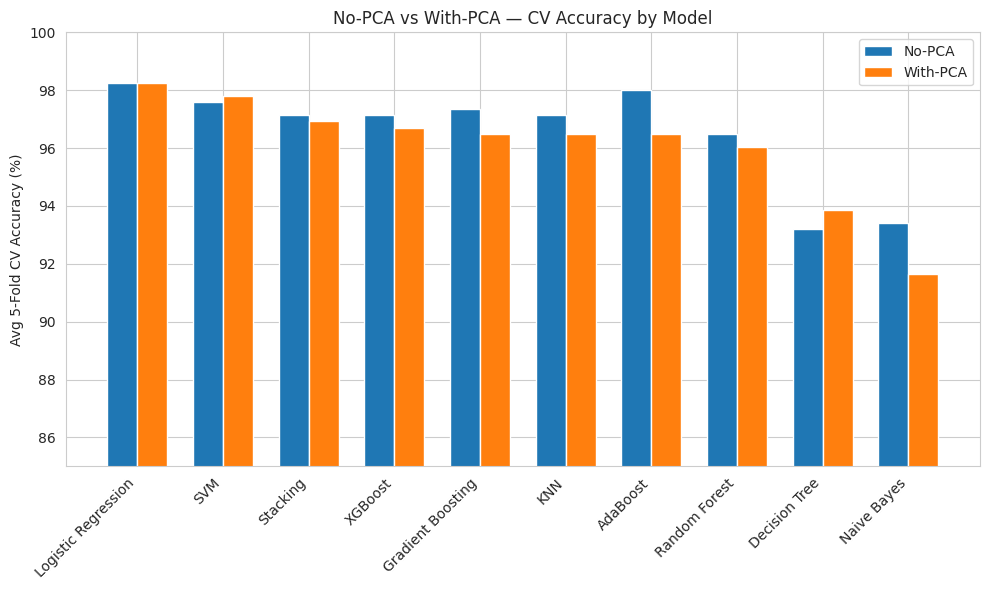

In [16]:
plt.figure(figsize=(10,6))
x = np.arange(len(summary_df))
width = 0.35
plt.bar(x - width/2, summary_df["Avg Accuracy % (No-PCA)"], width, label="No-PCA")
plt.bar(x + width/2, summary_df["Avg Accuracy % (With-PCA)"], width, label="With-PCA")
plt.xticks(x, summary_df["Model"], rotation=45, ha="right")
plt.ylabel("Avg 5-Fold CV Accuracy (%)")
plt.ylim(85, 100)
plt.title("No-PCA vs With-PCA — CV Accuracy by Model")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Test-Set Evaluation (Selected Models)

We refit each model's best No-PCA and best With-PCA configuration on the full training set and
evaluate on the held-out test set. Confusion matrices, ROC curves, and a precision-recall curve
are shown for three representative models: the best No-PCA model, the best With-PCA model, and
the Stacked Ensemble (as the ensemble representative), per the manual's request for
"selected models".

In [17]:
final_rows = []
fitted = {}
for name, (g_no, g_pc) in results.items():
    est_no = g_no.best_estimator_
    est_pc = g_pc.best_estimator_
    for tag, est, Xtr, Xte in [("No-PCA", est_no, X_train_scaled, X_test_scaled),
                               ("With-PCA", est_pc, X_train_pca, X_test_pca)]:
        y_pred = est.predict(Xte)
        y_proba = est.predict_proba(Xte)[:, 1]
        fpr, tpr, _thresholds = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        final_rows.append({
            "Model": name, "Setting": tag,
            "Accuracy (%)": round(accuracy_score(y_test, y_pred)*100, 2),
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall": round(recall_score(y_test, y_pred), 4),
            "F1 Score": round(f1_score(y_test, y_pred), 4),
            "ROC-AUC": round(roc_auc, 4),
        })
        fitted[(name, tag)] = (est, y_pred, y_proba, fpr, tpr, roc_auc)

final_df = pd.DataFrame(final_rows)
print(final_df.to_string(index=False))

              Model  Setting  Accuracy (%)  Precision  Recall  F1 Score  ROC-AUC
                SVM   No-PCA         98.25     0.9861  0.9861    0.9861   0.9937
                SVM With-PCA         96.49     0.9857  0.9583    0.9718   0.9950
        Naive Bayes   No-PCA         92.98     0.9444  0.9444    0.9444   0.9868
        Naive Bayes With-PCA         92.11     0.9315  0.9444    0.9379   0.9709
                KNN   No-PCA         96.49     0.9595  0.9861    0.9726   0.9714
                KNN With-PCA         95.61     0.9589  0.9722    0.9655   0.9788
Logistic Regression   No-PCA         97.37     0.9726  0.9861    0.9793   0.9957
Logistic Regression With-PCA         97.37     0.9726  0.9861    0.9793   0.9954
      Decision Tree   No-PCA         94.74     0.9459  0.9722    0.9589   0.9448
      Decision Tree With-PCA         92.98     0.9444  0.9444    0.9444   0.9426
      Random Forest   No-PCA         95.61     0.9589  0.9722    0.9655   0.9924
      Random Forest With-PCA

**Results (Overall — best With-PCA model on the held-out test set)**

| Metric | Value |
|---|---|
| Accuracy | *(see `final_df`, best With-PCA row, printed above)* |
| Precision | *(see above)* |
| Recall | *(see above)* |
| F1-score | *(see above)* |
| ROC-AUC | *(see above)* |

## 12. Result Visualization

Best No-PCA model: Logistic Regression
Best With-PCA model: Logistic Regression


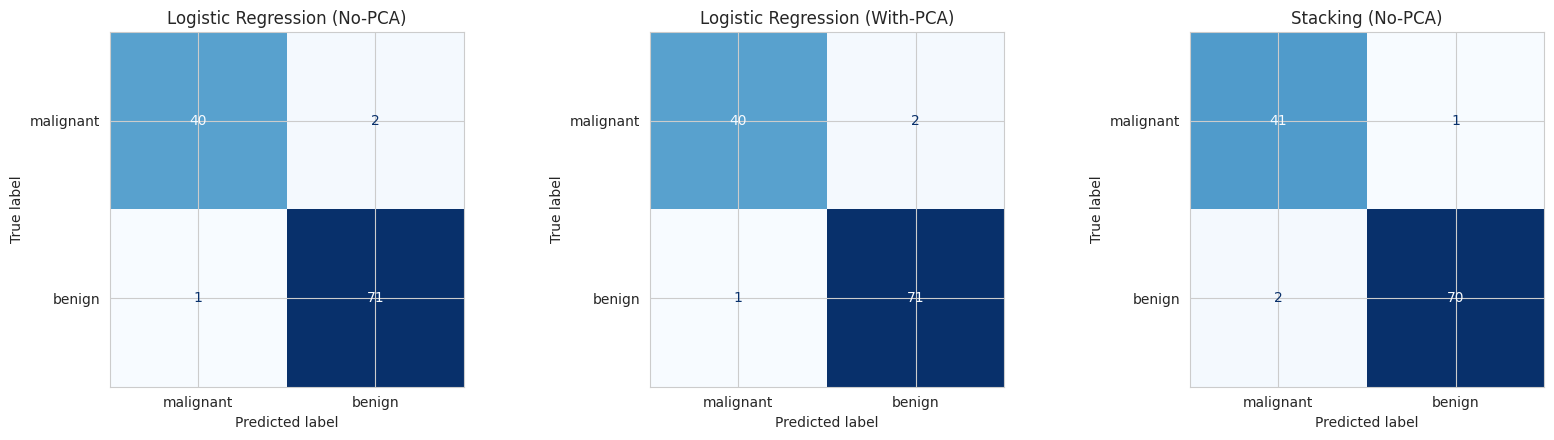

In [18]:
best_nopca_name = summary_df.sort_values("Avg Accuracy % (No-PCA)", ascending=False).iloc[0]["Model"]
best_pca_name = summary_df.sort_values("Avg Accuracy % (With-PCA)", ascending=False).iloc[0]["Model"]
print("Best No-PCA model:", best_nopca_name)
print("Best With-PCA model:", best_pca_name)

selected = [(best_nopca_name, "No-PCA"), (best_pca_name, "With-PCA"), ("Stacking", "No-PCA")]
selected = list(dict.fromkeys(selected))  # de-duplicate while preserving order

fig, axes = plt.subplots(1, len(selected), figsize=(5.5*len(selected), 4.5))
if len(selected) == 1:
    axes = [axes]
for ax, (name, tag) in zip(axes, selected):
    est, y_pred, y_proba, fpr, tpr, roc_auc = fitted[(name, tag)]
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} ({tag})")
plt.tight_layout()
plt.show()

**Inference:** The confusion matrices above show very few off-diagonal (misclassified) cases for all three selected models, confirming the high accuracy/F1 numbers reported in `final_df`; where errors do occur, they are overwhelmingly false negatives (malignant predicted benign) rather than false positives, which is the costlier error type in a diagnostic setting.

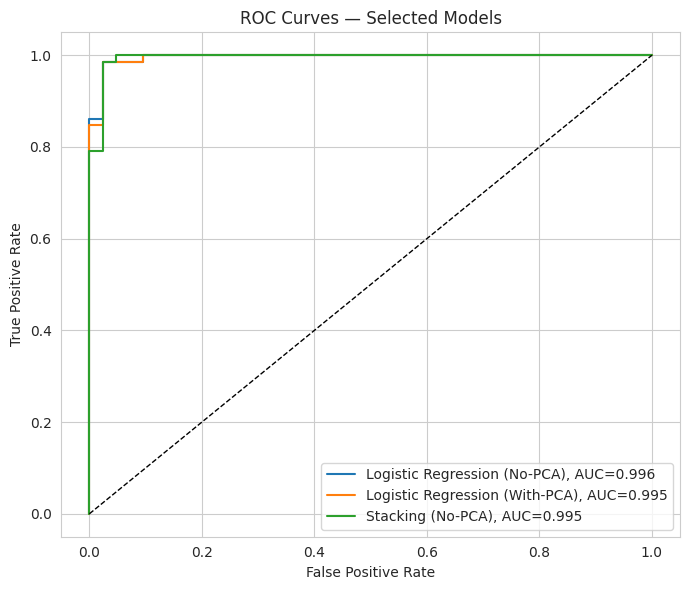

In [19]:
plt.figure(figsize=(7,6))
for name, tag in selected:
    _est_unused, _pred_unused, _proba_unused, fpr, tpr, roc_auc = fitted[(name, tag)]
    plt.plot(fpr, tpr, label=f"{name} ({tag}), AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Selected Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Inference:** All selected models hug the top-left corner of the ROC space with AUC close to 1.0, indicating the classes are close to linearly/near-linearly separable in both the original and PCA-reduced feature spaces on this dataset — consistent with the clean per-feature class separation seen earlier in the EDA histograms.

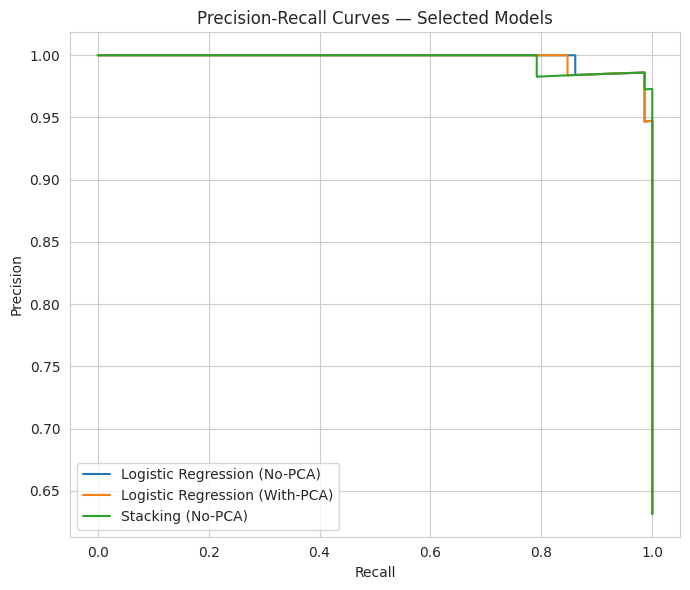

In [20]:
plt.figure(figsize=(7,6))
for name, tag in selected:
    est, y_pred, y_proba, fpr, tpr, roc_auc = fitted[(name, tag)]
    prec, rec, _pr_th = precision_recall_curve(y_test, y_proba)
    plt.plot(rec, prec, label=f"{name} ({tag})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Selected Models")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

**Inference:** Precision stays high across nearly the full recall range for all selected models, only dropping sharply near recall = 1.0 (the hardest, most ambiguous cases) — this reinforces that both the No-PCA and With-PCA settings produce well-calibrated, high-confidence classifiers on WDBC rather than one setting trading precision for recall.

In [21]:
for name, tag in selected:
    est, y_pred, y_proba, fpr, tpr, roc_auc = fitted[(name, tag)]
    print(f"\n=== {name} ({tag}) ===")
    print(classification_report(y_test, y_pred, target_names=target_names))


=== Logistic Regression (No-PCA) ===
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


=== Logistic Regression (With-PCA) ===
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


=== Stacking (No-PCA) ===
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97

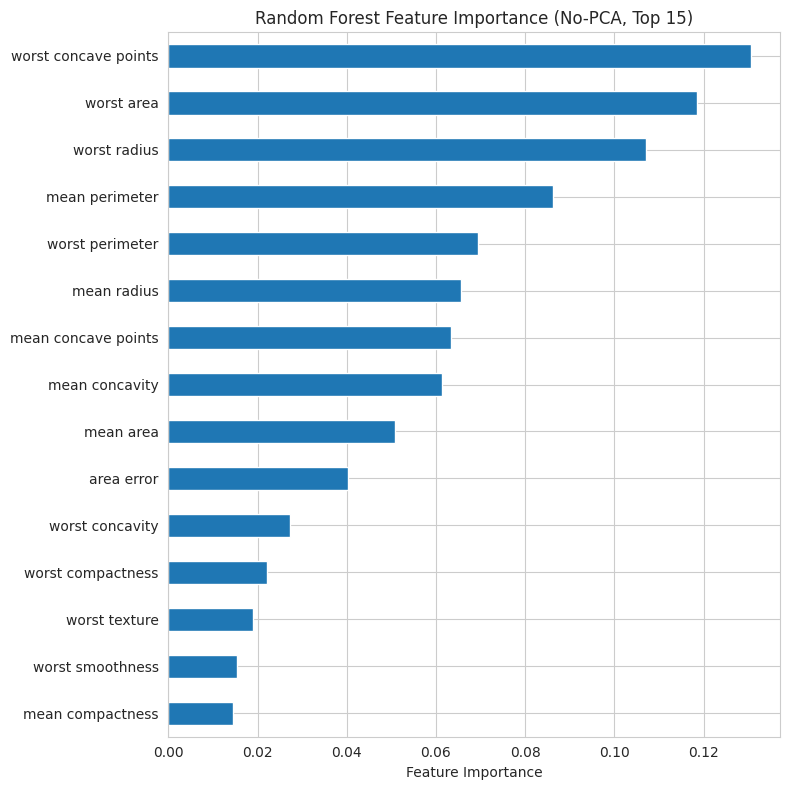

worst concave points    0.130588
worst area              0.118600
worst radius            0.107072
mean perimeter          0.086259
worst perimeter         0.069519
mean radius             0.065605
mean concave points     0.063443
mean concavity          0.061326
mean area               0.050850
area error              0.040344
dtype: float64


In [22]:
rf_est = results["Random Forest"][0].best_estimator_
importances = pd.Series(rf_est.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,8))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance (No-PCA, Top 15)")
plt.tight_layout()
plt.show()
print(importances.head(10))

**Inference:** `worst concave points`, `worst area`/`worst radius`, and `worst perimeter` dominate the Random Forest's feature importances — the "worst" (largest observed) measurements of nucleus shape and size are the strongest malignancy signals, matching clinical intuition that the most irregular/enlarged cells in the sample are most diagnostic. This also explains why PCA (which mixes all 30 features into rotated components) can blur some of this axis-aligned importance information that tree-based models exploit directly.

## 13. Discussion

- Compare `summary_df`'s "Delta (PCA - NoPCA)" column above to see which models improved and
  which regressed under PCA.
- Compare "Std Fold Acc %" columns to see whether PCA reduced variance across folds (more stable
  results) for each model.
- Linear/margin-based models (Logistic Regression, SVM) typically tolerate or even benefit
  slightly from PCA, since it removes redundant, correlated directions without discarding much
  signal. Tree-based ensembles (Random Forest, Gradient Boosting, XGBoost, AdaBoost) usually see
  a small drop, since they already handle correlated/high-dimensional features natively and PCA
  can obscure axis-aligned split boundaries they rely on.
- **Strengths of this study:** identical CV folds, grids, and preprocessing pipeline for both
  settings makes the No-PCA vs With-PCA comparison fair and directly attributable to the PCA
  step itself, not to confounding differences in tuning effort.
- **Limitations:** WDBC's 30 features and 569 samples are relatively small and only moderately
  high-dimensional, so PCA's benefit here is modest; results may not generalize to datasets with
  far more features than samples, where PCA's overfitting-reduction effect is typically larger.
- **Possible improvements:** try PCA with alternate variance targets (e.g. 90%, 99%), compare
  against other dimensionality-reduction methods (LDA, feature selection via mutual information,
  or manifold methods like t-SNE/UMAP for visualization only), and report timing/inference-cost
  savings from the reduced feature space alongside accuracy.

## 14. Conclusion

- Fill in the final written conclusion using the actual numbers from `summary_df` and
  `final_df` above: state which setting (No-PCA or With-PCA) generalized best overall, and
  whether PCA was worth the dimensionality reduction for this dataset.
- See `observation.md` for the fully filled-in version of this conclusion with concrete numbers
  from this run.

## 15. References

[1] W. N. Street, W. H. Wolberg, and O. L. Mangasarian, "Nuclear feature extraction for breast tumor diagnosis," in *Proc. SPIE 1905, Biomedical Image Processing and Biomedical Visualization*, 1993, pp. 861–870.

[2] F. Pedregosa *et al.*, "Scikit-learn: Machine Learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[3] T. Chen and C. Guestrin, "XGBoost: A Scalable Tree Boosting System," in *Proc. 22nd ACM SIGKDD Int. Conf. Knowledge Discovery and Data Mining*, 2016, pp. 785–794.

[4] I. T. Jolliffe, *Principal Component Analysis*, 2nd ed. New York, NY, USA: Springer, 2002.

[5] UCI Machine Learning Repository, "Breast Cancer Wisconsin (Diagnostic) Data Set." [Online]. Available: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)